In [1]:
# 데이터 선택
# 전처리 (결측치, 이상치, 표준화)
# 1. 모델 선택
# 2. 모델 학습
# 3. 모델 평가
# 1-2-3 반복하면서 모델 평가

In [1]:
# 시험환경 세팅 (코드 변경 X)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

def exam_data_load(df, target, id_name="", null_name=""):
    if id_name == "":
        df = df.reset_index().rename(columns={"index": "id"})
        id_name = 'id'
    else:
        id_name = id_name
    
    if null_name != "":
        df[df == null_name] = np.nan
    
    X_train, X_test = train_test_split(df, test_size=0.2, random_state=2021)
    
    y_train = X_train[[id_name, target]]
    X_train = X_train.drop(columns=[target])

    
    y_test = X_test[[id_name, target]]
    X_test = X_test.drop(columns=[target])
    return X_train, X_test, y_train, y_test 
    
df = pd.read_csv(r"C:\git_test\Machine Learning\datasets\diabetes.csv")
X_train, X_test, y_train, y_test = exam_data_load(df, target='Outcome')

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((614, 9), (154, 9), (614, 2), (154, 2))

In [2]:
# id drop
X_train.drop('id', axis=1, inplace=True)
X_test.drop('id', axis=1, inplace=True)
y_train.drop('id', axis=1, inplace=True)
y_test.drop('id', axis=1, inplace=True)
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
147,2,106,64,35,119,30.5,1.400,34
344,8,95,72,0,0,36.8,0.485,57
390,1,100,66,29,196,32.0,0.444,42
150,1,136,74,50,204,37.4,0.399,24
132,3,170,64,37,225,34.5,0.356,30
...,...,...,...,...,...,...,...,...
621,2,92,76,20,0,24.2,1.698,28
128,1,117,88,24,145,34.5,0.403,40
57,0,100,88,60,110,46.8,0.962,31
341,1,95,74,21,73,25.9,0.673,36


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

y_train = y_train.squeeze()
y_test = y_test.squeeze()

sgd_pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('rdf', SGDClassifier(random_state=42))
])

sdg_y_predict = cross_val_predict(sgd_pipeline, X_test, y_test, cv=5)
print(classification_report(y_test, sdg_y_predict))

random_pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('rand', RandomForestClassifier(random_state=42, n_estimators=500))
])
random_y_predict = cross_val_predict(random_pipeline, X_test, y_test, cv=5)
print(classification_report(y_test, random_y_predict))

logis_pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('logis', LogisticRegression())
])
logis_y_predict = cross_val_predict(logis_pipeline, X_test, y_test, cv=5)
print(classification_report(y_test, logis_y_predict))

              precision    recall  f1-score   support

           0       0.76      0.81      0.79        97
           1       0.64      0.56      0.60        57

    accuracy                           0.72       154
   macro avg       0.70      0.69      0.69       154
weighted avg       0.72      0.72      0.72       154

              precision    recall  f1-score   support

           0       0.77      0.86      0.81        97
           1       0.70      0.56      0.62        57

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154

              precision    recall  f1-score   support

           0       0.78      0.82      0.80        97
           1       0.67      0.61      0.64        57

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.74      0.75      0.74       154



In [10]:
print(y_train.shape)
print(type(y_train))

(614, 1)
<class 'pandas.core.frame.DataFrame'>


In [14]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 614 entries, 147 to 116
Series name: Outcome
Non-Null Count  Dtype
--------------  -----
614 non-null    int64
dtypes: int64(1)
memory usage: 9.6 KB


147    0
344    0
390    0
150    0
132    1
      ..
621    0
128    1
57     0
341    0
116    1
Name: Outcome, Length: 614, dtype: int64

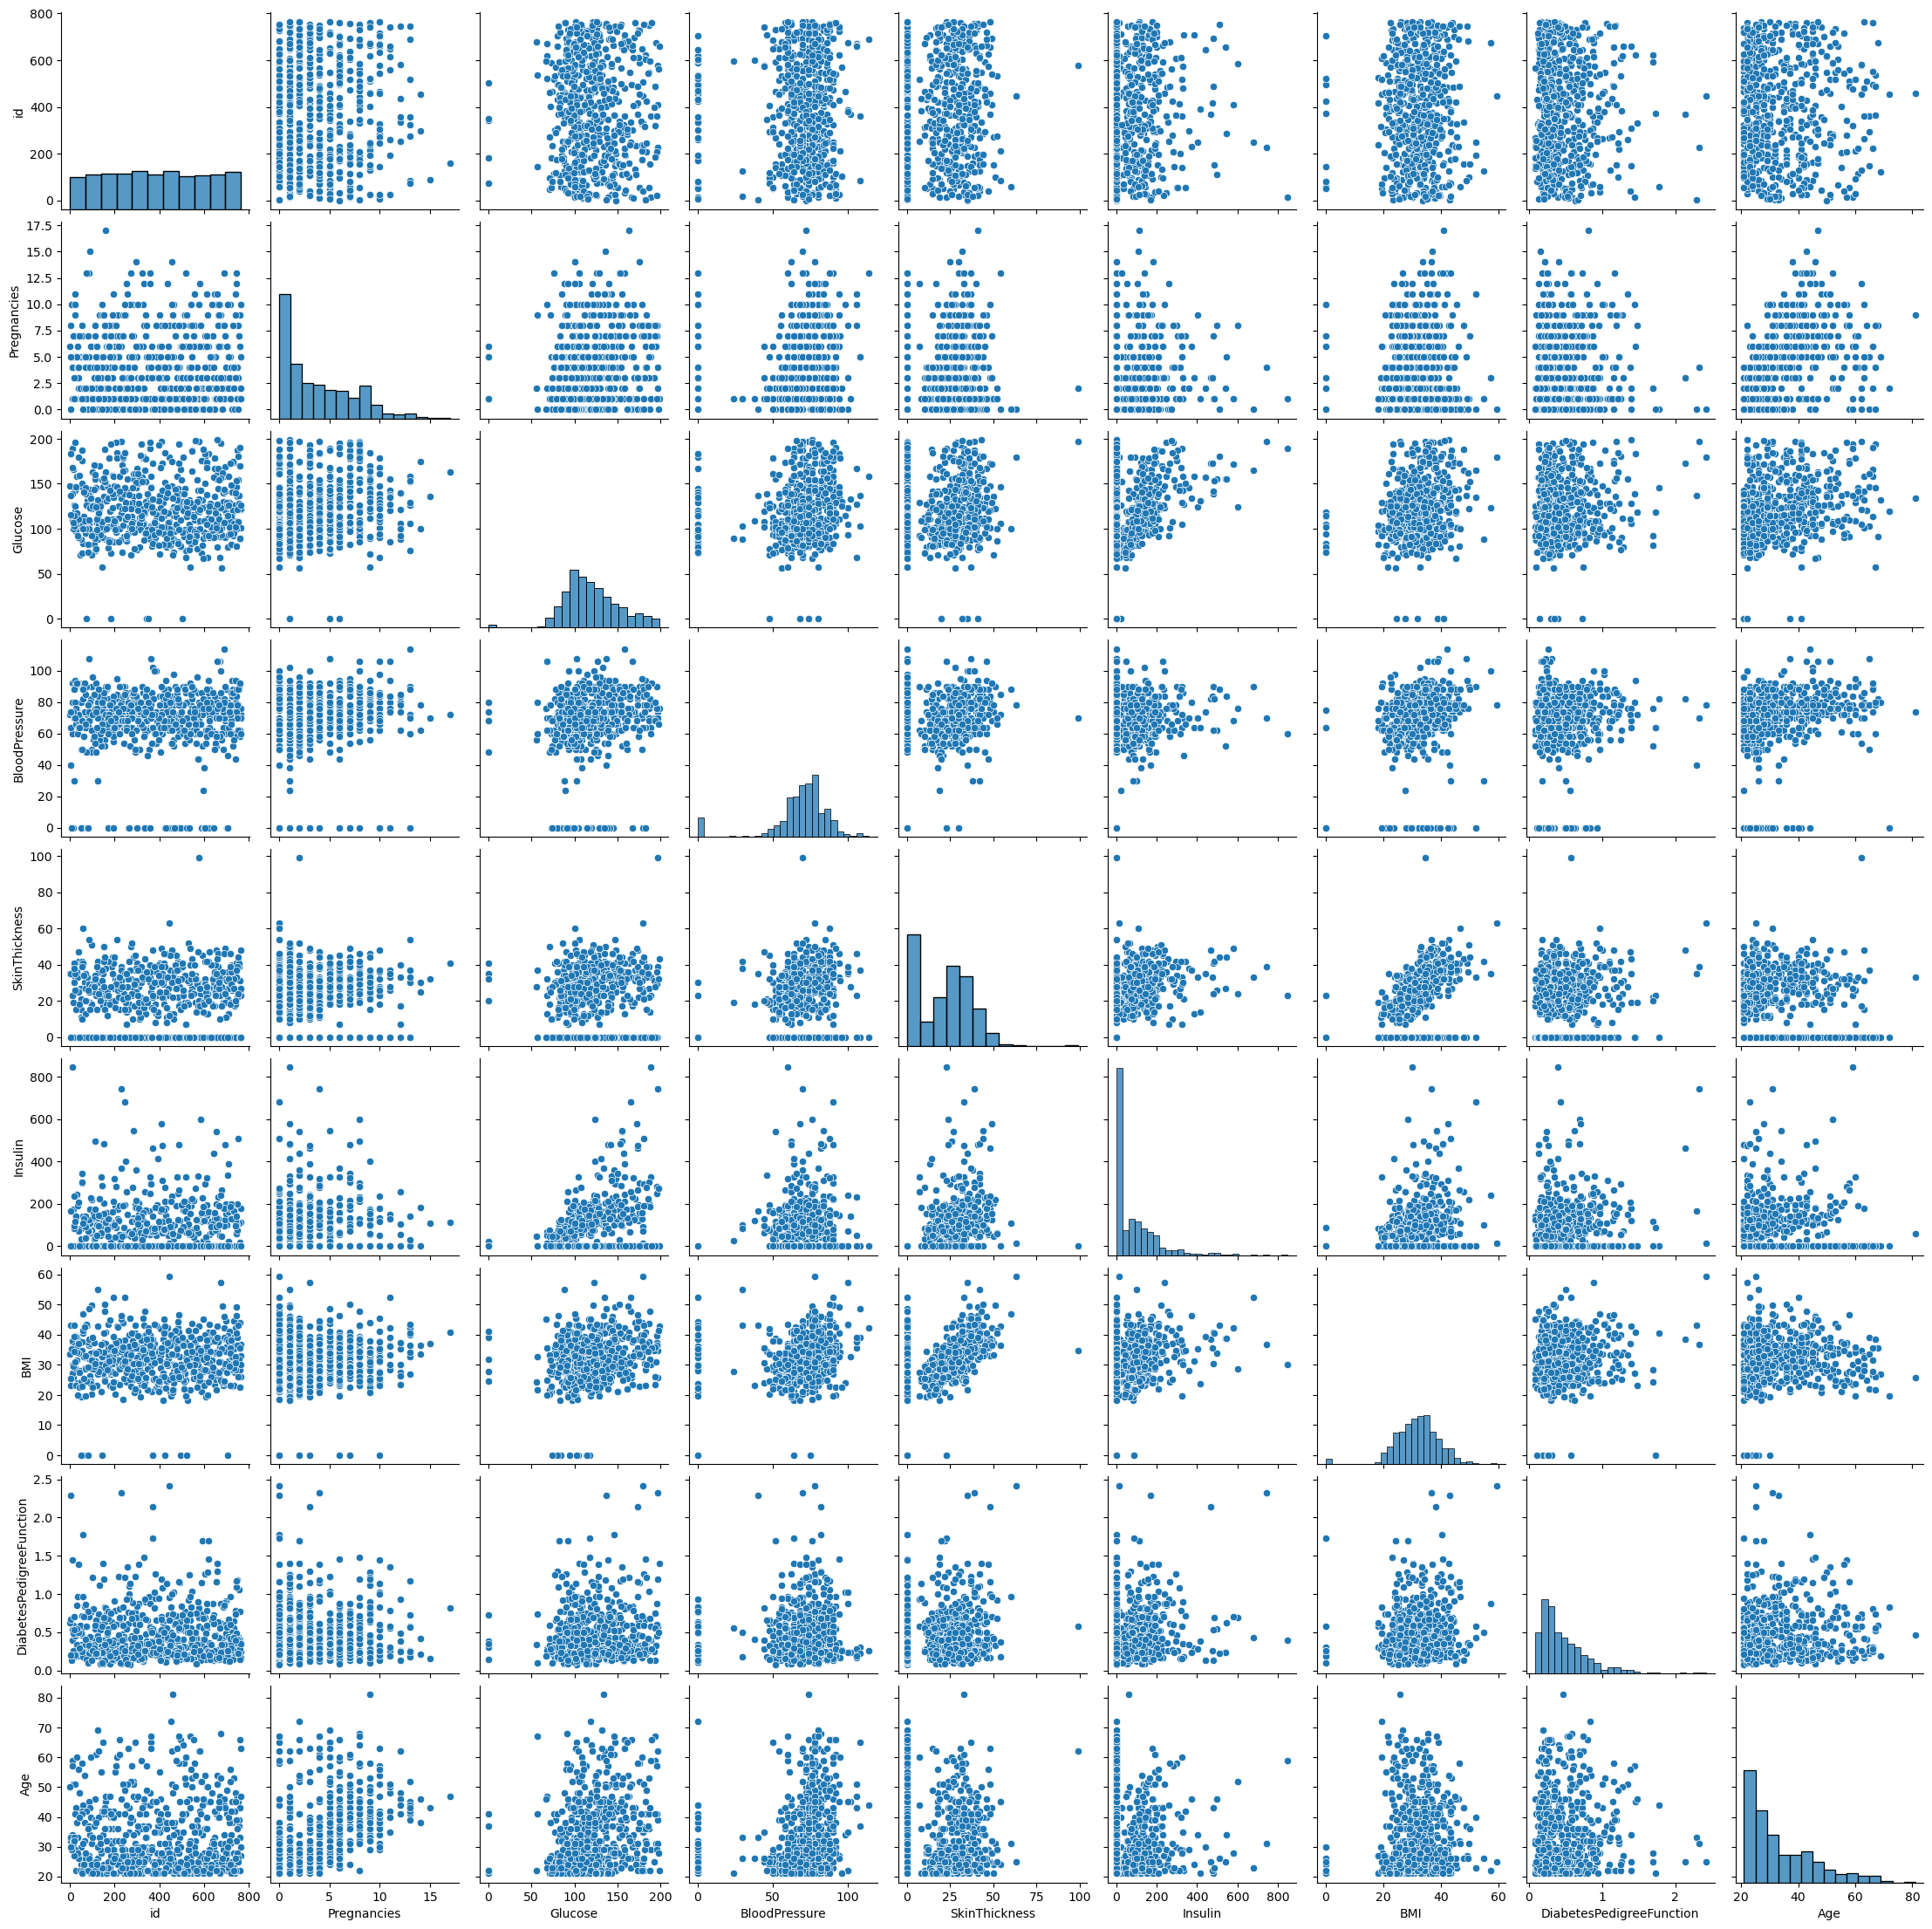

In [18]:
import seaborn as sns
sns.pairplot(X_train)

In [15]:
X_test.isnull().sum()

id                          0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

In [16]:
help(df.drop)

Help on method drop in module pandas.core.frame:

drop(labels: 'IndexLabel | None' = None, *, axis: 'Axis' = 0, index: 'IndexLabel | None' = None, columns: 'IndexLabel | None' = None, level: 'Level | None' = None, inplace: 'bool' = False, errors: 'IgnoreRaise' = 'raise') -> 'DataFrame | None' method of pandas.core.frame.DataFrame instance
    Drop specified labels from rows or columns.
    
    Remove rows or columns by specifying label names and corresponding
    axis, or by directly specifying index or column names. When using a
    multi-index, labels on different levels can be removed by specifying
    the level. See the :ref:`user guide <advanced.shown_levels>`
    for more information about the now unused levels.
    
    Parameters
    ----------
    labels : single label or list-like
        Index or column labels to drop. A tuple will be used as a single
        label and not treated as a list-like.
    axis : {0 or 'index', 1 or 'columns'}, default 0
        Whether to drop l